# Pandas 速通版本

## 基础

### 从Python**字典**生成DataFrame表格

In [7]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt

# 创建表格
workout_dict = {
    '日期': ['2023-01-01', '2023-01-02', '2023-01-03'],
    '运动类型': ['跑步', '游泳', '骑行'],
    '时长(分钟)': [30, 45, 60],
    '距离(公里)': [5, 2, 15]
}

# 将字典转换为DataFrame
workout_dict = pd.DataFrame(workout_dict)
display(workout_dict) # 显示表格内容

,日期,运动类型,时长(分钟),距离(公里)
0,2023-01-01,跑步,30,5
1,2023-01-02,游泳,45,2
2,2023-01-03,骑行,60,15


### 列索引与行索引

In [8]:
print(workout_dict.columns)  # 打印表格的列名
print(workout_dict.index)    # 打印表格的索引

print(workout_dict['日期'])  # 打印“日期”列

#其他数据类型转换方法： tolist(), to_numpy()，to_dict()
print(workout_dict.columns.tolist())  # 将列名转换为列表
print(workout_dict.index.tolist())  # 将索引转换为列表

Index(['日期', '运动类型', '时长(分钟)', '距离(公里)'], dtype='object')
RangeIndex(start=0, stop=3, step=1)
0    2023-01-01
1    2023-01-02
2    2023-01-03
Name: 日期, dtype: object
['日期', '运动类型', '时长(分钟)', '距离(公里)']
[0, 1, 2]


### DataFrame 单独指定/改变索引

In [9]:
# 直接重新赋值行索引
workout_dict.index = ['A', 'B', 'C']
# 直接重新赋值列索引
workout_dict.columns = ['Date', 'Activity', 'Duration', 'Distance']
print(workout_dict)

# 单独改变某一列列名
workout_dict.rename(columns={'Date': '日期'}, inplace=True)
print(workout_dict)

# 转回dict字典
workout_dict_dict = workout_dict.to_dict()
print(workout_dict_dict)  # 打印转换后的字典

         Date Activity  Duration  Distance
A  2023-01-01       跑步        30         5
B  2023-01-02       游泳        45         2
C  2023-01-03       骑行        60        15
           日期 Activity  Duration  Distance
A  2023-01-01       跑步        30         5
B  2023-01-02       游泳        45         2
C  2023-01-03       骑行        60        15
{'日期': {'A': '2023-01-01', 'B': '2023-01-02', 'C': '2023-01-03'}, 'Activity': {'A': '跑步', 'B': '游泳', 'C': '骑行'}, 'Duration': {'A': 30, 'B': 45, 'C': 60}, 'Distance': {'A': 5, 'B': 2, 'C': 15}}


### 访问代码中的列与行

In [10]:
#选择第一列
print(workout_dict.iloc[:, 0])  # 选择第一列
#选择第一行 
print(workout_dict.iloc[0, :])  # 选择第一行

# 通过名字
print(workout_dict.loc[:, '日期'])  # 选择“日期”列
print(workout_dict['日期'])  # 选择“日期”列

A    2023-01-01
B    2023-01-02
C    2023-01-03
Name: 日期, dtype: object
日期          2023-01-01
Activity            跑步
Duration            30
Distance             5
Name: A, dtype: object
A    2023-01-01
B    2023-01-02
C    2023-01-03
Name: 日期, dtype: object
A    2023-01-01
B    2023-01-02
C    2023-01-03
Name: 日期, dtype: object


### 外部数据的导入


In [11]:
coffee_consumption = pd.read_csv('coffee_consumption.csv')  # 读取CSV文件
# 常用参数：index_col, header, names, usecols, dtype, sep（分隔符）, encoding（编码格式）

## 数据显示

In [12]:
# 显示数据
print(coffee_consumption.head())  # 显示前5行数据(默认)
print(coffee_consumption.tail(2))  # 显示最后3行数据
print(coffee_consumption.shape)  # 打印数据的形状（行数, 列数）
print(coffee_consumption.columns)  # 打印列名
print(coffee_consumption.index)  # 打印索引 
print(coffee_consumption.dtypes())  # 打印每列的数据类型

    国家    年份  人均年消费量(kg) 最受欢迎咖啡类型  平均单杯价格(美元)  咖啡馆数量/10万人 是否有本土咖啡品牌  \
0  意大利  2020         6.2     浓缩咖啡         1.8        12.5         是   
1  意大利  2021         6.3     浓缩咖啡         1.9        12.8         是   
2  意大利  2022         6.1     浓缩咖啡         2.1        12.6         是   
3   美国  2020         4.2     美式咖啡         3.5         8.2         是   
4   美国  2021         4.5     冷萃咖啡         3.7         8.5         是   

   年度咖啡进口额(百万美元)  
0            450  
1            465  
2            480  
3           1200  
4           1250  
    国家    年份  人均年消费量(kg) 最受欢迎咖啡类型  平均单杯价格(美元)  咖啡馆数量/10万人 是否有本土咖啡品牌  \
22  英国  2021         2.9     卡布奇诺         3.2         7.8         否   
23  英国  2022         3.0       拿铁         3.3         8.0         否   

    年度咖啡进口额(百万美元)  
22            730  
23            740  
(24, 8)
Index(['国家', '年份', '人均年消费量(kg)', '最受欢迎咖啡类型', '平均单杯价格(美元)', '咖啡馆数量/10万人',
       '是否有本土咖啡品牌', '年度咖啡进口额(百万美元)'],
      dtype='object')
RangeIndex(start=0, stop=24, step=1)


TypeError: 'Series' object is not callable

## 查看数据元信息和描述性统计数据
- .info：
  - 打印数据行数列数
  - 列名，非空值数量，数据类型
  - 内存占用

In [ ]:
print(coffee_consumption.info)  # 打印数据的基本信息

- .describe:仅计算数据类型的类
  - count：非空值数量
  - mean：平均值
  - std：标准差（衡量数据离散程度）
  - min/max：最小值 / 最大值
  - 25%/50%/75%：四分位数（将数据从小到大排序后，分割为四等分的点）

In [ ]:
print(coffee_consumption.describe) # 打印数据的统计信息

### .unique()
得到序列中出现过的值

In [ ]:
print(coffee_consumption['人均年消费量(kg)'].unique())  # 得到“人均年消费量(kg)”列中出现过的值
print(coffee_consumption['人均年消费量(kg)'].nunique())  # 得到“人均年消费量(kg)”列中不同值的数量

[6.2 6.3 6.1 4.2 4.5 4.7 3.8 3.9 4.  5.1 5.3 5.5 5.9 6.  5.8 1.2 1.5 1.8
 3.2 3.3 3.5 2.8 2.9 3. ]
24


### df.groupby()：分类统计信息
- 根据列的值的分类，对每一个类型统计信息

In [ ]:
print(coffee_consumption[['平均单杯价格(美元)','国家']].groupby('国家').mean())  # 按“国家”分组，计算“平均单杯价格(美元)”的平均值
print(coffee_consumption.groupby('国家').agg({'人均年消费量(kg)': ['mean', 'max', 'min']}))  # 按“国家”分组，计算“人均年消费量(kg)”的平均值、最大值和最小值

### 动态选择记录

In [ ]:
filter = coffee_consumption['人均年消费量(kg)'] > 5  # 创建过滤条件
print(coffee_consumption[filter])  # 打印满足过滤条件的行

filter1 = (~coffee_consumption['人均年消费量(kg)'].isnull())  # 创建过滤条件，排除空值
# 使用 ~ 运算符来取反，另外还有&和 | 运算符用于按位与或操作
print(coffee_consumption[filter1])  # 打印不包含空值的行

     国家    年份  人均年消费量(kg) 最受欢迎咖啡类型  平均单杯价格(美元)  咖啡馆数量/10万人 是否有本土咖啡品牌  \
0   意大利  2020         6.2     浓缩咖啡         1.8        12.5         是   
1   意大利  2021         6.3     浓缩咖啡         1.9        12.8         是   
2   意大利  2022         6.1     浓缩咖啡         2.1        12.6         是   
9    巴西  2020         5.1      黑咖啡         1.2         5.3         是   
10   巴西  2021         5.3      黑咖啡         1.3         5.5         是   
11   巴西  2022         5.5      黑咖啡         1.4         5.7         是   
12   法国  2020         5.9       拿铁         2.5        10.8         是   
13   法国  2021         6.0       拿铁         2.6        11.0         是   
14   法国  2022         5.8     卡布奇诺         2.8        10.9         是   

    年度咖啡进口额(百万美元)  
0             450  
1             465  
2             480  
9             180  
10            190  
11            200  
12            680  
13            690  
14            700  
       国家    年份  人均年消费量(kg) 最受欢迎咖啡类型  平均单杯价格(美元)  咖啡馆数量/10万人 是否有本土咖啡品牌  \
0    

### .agg()：一次获得多种信息
- 基本语法：`df.agg(func=None, axis=0, *args, **kwargs)`

In [ ]:
cf_agg = coffee_consumption.agg(
    '人均年消费量(kg)': ['mean', 'max', 'min'] ) # 对“人均年消费量(kg)”列进行多种统计

## 常用工作流程

### 字符串的处理
1. 使用 str 预定义的函数
   1. str.upper:所有小写字母转换为大写字母
   2. str.lower:所有大写字母转换为小写字母
   3. str.len：取字符的长度
   4. str.strip,lstrip,rstrip:去除前后空格
   5. str.replace("a","b"):将str中的a替换为b
   6. str.split('a'):用a来分割字符串
2. 直接拼接
3. 使用`apply`函数：`series.apply(func, args=(), **kwargs)` or `df['列名'].apply(func, args=(), **kwargs)` 即传入自定义函数func来处理series或者DataFrame

In [ ]:
df = coffee_consumption['咖啡馆数量/10万人'].apply(lambda x: x * 10)  # 将“咖啡馆数量/10万人”列的值乘以10
print(df)  # 打印转换后的数据

### 时间信息的处理

1. pd.to_datetime():转为时间格式
2. timeDalta：时间差数据
3. 序列中提供一系列的dt时间函数（与str函数很相似）

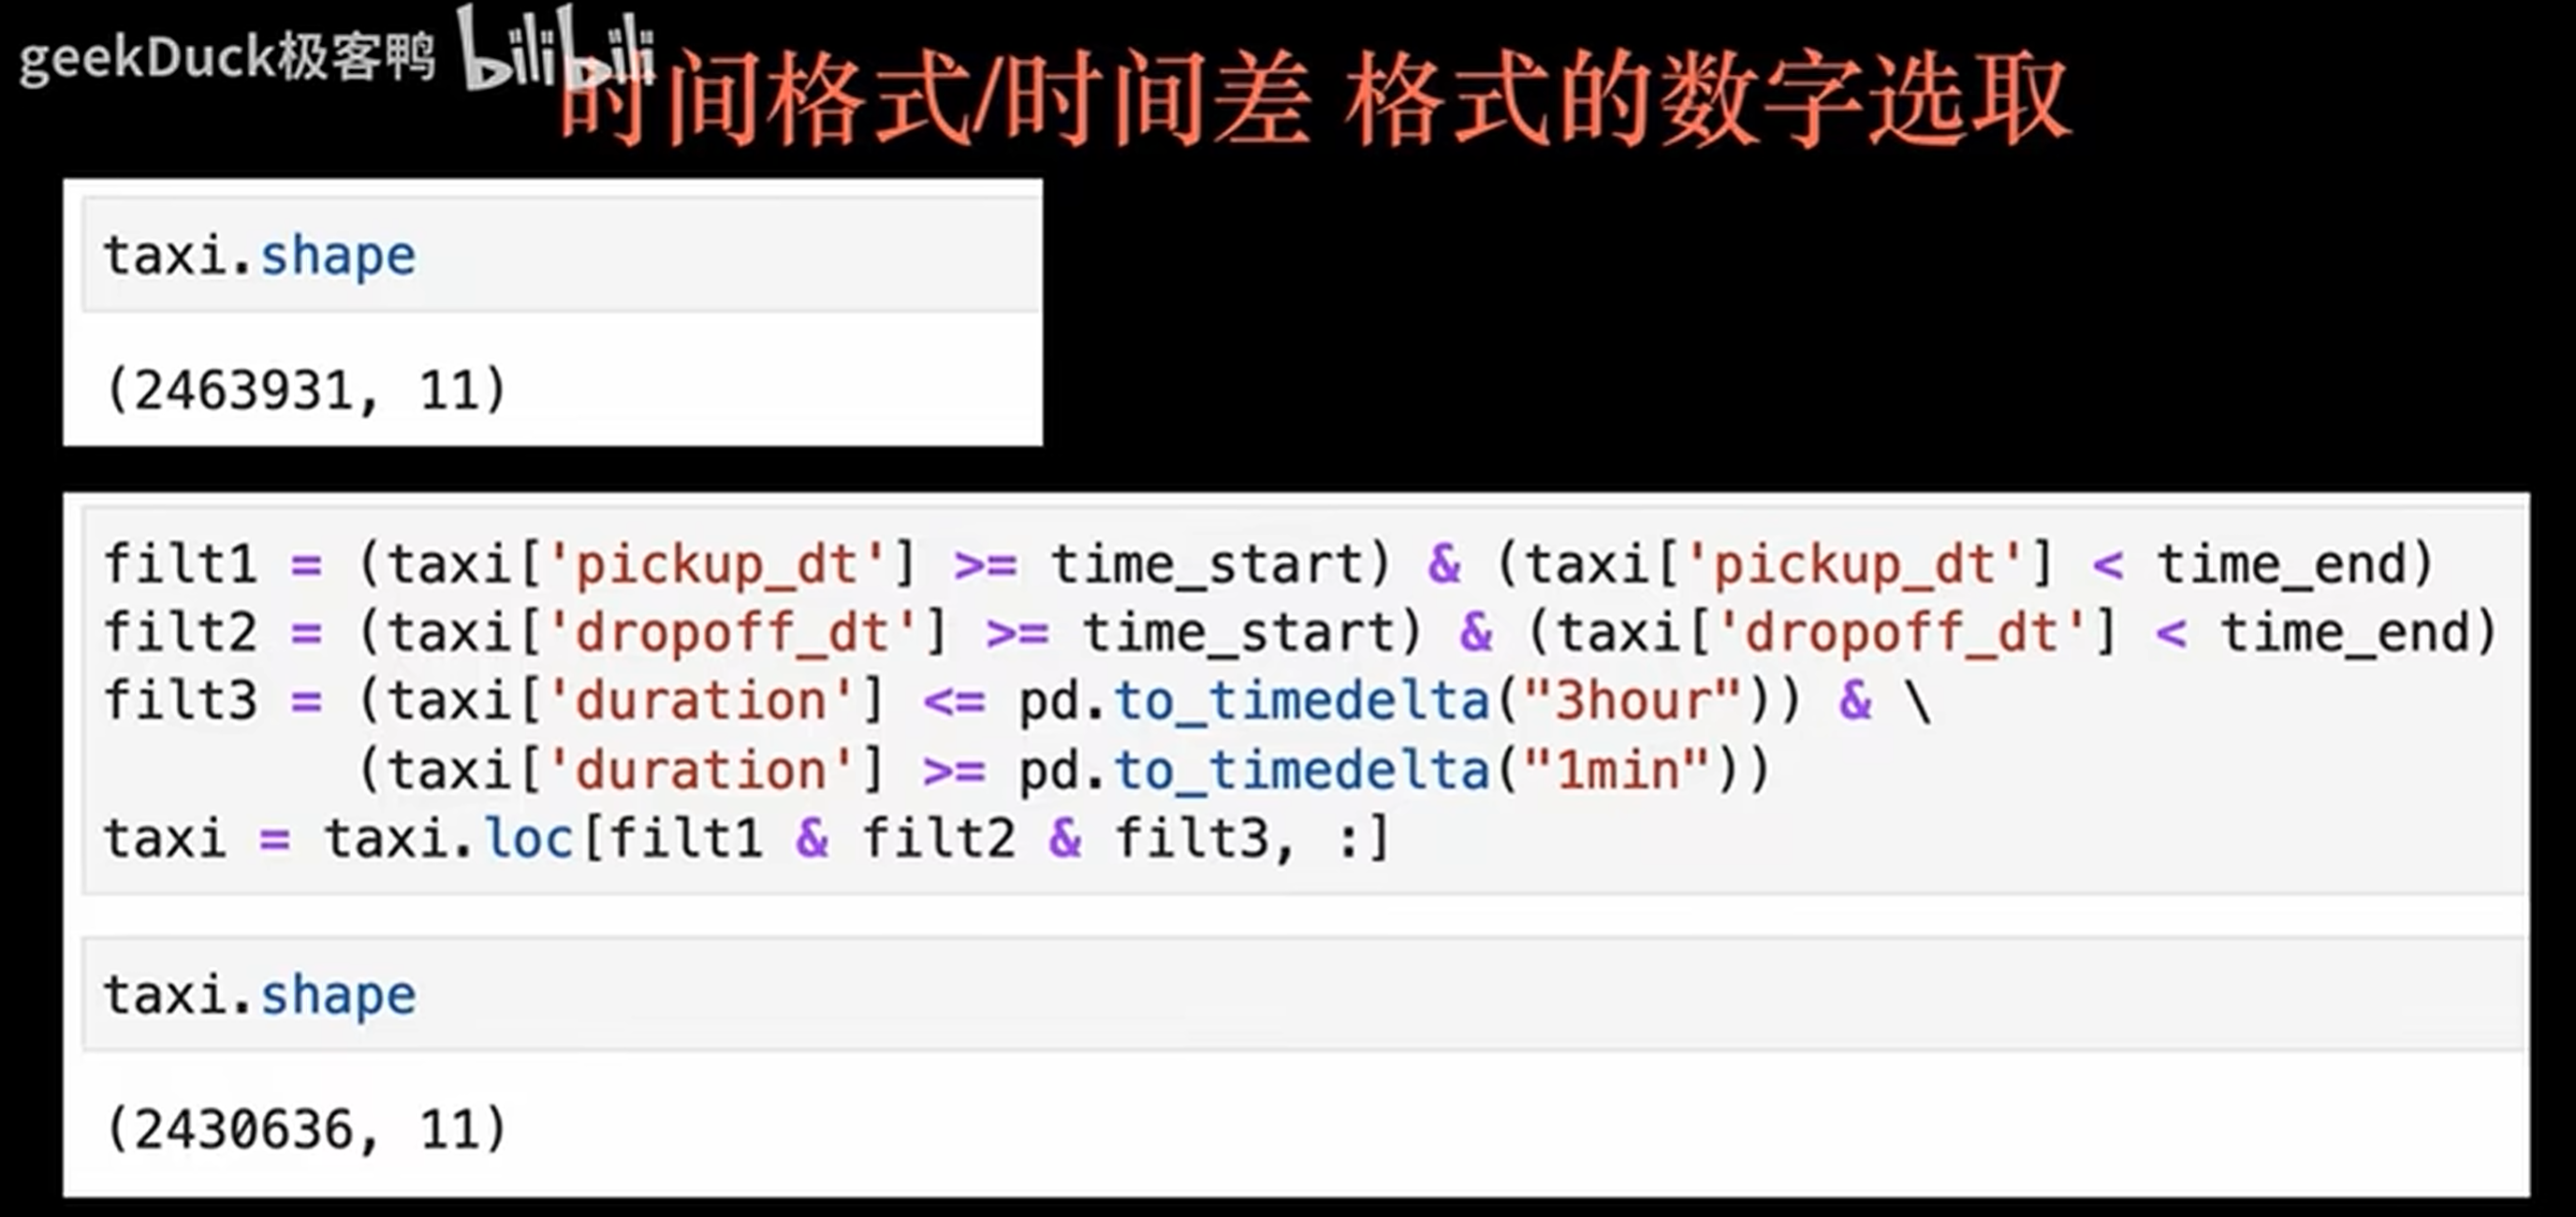

### 工作流1：split-apply-combine 分类统计今夕

1. `.groupby()`:按照列值将一个表格分为不同的小表
2. `.apply()`:针对每一个dataframe进行运算
3. `.filter()`:按照返回True或False序列对小组进项筛选

### 工作流2：表格排序

1. `.sort_values()`:按照列的值排序
2. `.rank()`：按照列的值排列返回名次信息
3. `.sort_index()`:按照索引值的大小排列

### 工作流3：表格拼接
1. `concat`：按照列or行的方向拼接
2. `join`：按照行索引index进行拼接
3. `merge`：按照列的值为依据进行拼接